## HAVEN Probability Distributions for Plant Sequences

The below analysis was conducted following adapting a config file and running an experiment using HAVEN given viruses that infect only plants (Virdiplantae: NCBI kingdom-classification for green plants).

### Loading data and importing libraries

In [2]:
# import appropriate directories for analysis
import pandas as pd
import os
from ete3 import NCBITaxa
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import numpy as np
from scipy.stats import entropy

file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "output/raw/uniref90-common-hosts/plants/msl256ae_bn_vs30cls_s64.csv")
df = pd.read_csv(file_path)
df

,uniref90_id,Capybara,Himalayan marmot,Human,Pig,Red junglefowl,y_true
0,UniRef90_A0A023HRI2,0.000348,0.019004,0.057019,0.005274,0.918354,Solanum tuberosum
1,UniRef90_A0A023I4L6,0.000176,0.000222,0.282891,0.094362,0.622349,Vitis vinifera
2,UniRef90_A0A023I4T0,0.075013,0.002791,0.303330,0.047233,0.571632,Phaseolus vulgaris
3,UniRef90_A0A023I4X6,0.248004,0.000120,0.128493,0.002418,0.620966,Phaseolus vulgaris
4,UniRef90_A0A023J729,0.047129,0.010038,0.555540,0.381926,0.005368,Cassia tora
...,...,...,...,...,...,...,...
7268,UniRef90_X5JA69,0.756238,0.000957,0.091977,0.000729,0.150098,Abelmoschus esculentus
7269,UniRef90_X5JAR6,0.163025,0.019147,0.396968,0.039026,0.381833,Abelmoschus esculentus
7270,UniRef90_X5JAZ3,0.626256,0.005547,0.295324,0.004258,0.068614,Solanum lycopersicum
7271,UniRef90_X5LY29,0.002937,0.419565,0.162297,0.377876,0.037325,Cajanus cajan


In [3]:
# prints the number of unique plant hosts
len(df['y_true'].value_counts())

911

In [4]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "output/raw/uniref90-common-hosts/plants/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_msl256s64allemb_vs30cls_batchnorm_hybrid_attention_msl256s64ae_fnn_2l_d1024_lr1e-4_output.csv")
vert_df = pd.read_csv(file_path)
vert_df

,Unnamed: 0,Capybara,Himalayan marmot,Human,Pig,Red junglefowl,y_true,itr
0,0,0.034830,0.003839,0.866651,0.008842,0.085837,Human,0
1,1,0.002989,0.002727,0.486508,0.491108,0.016668,Human,0
2,2,0.005151,0.001573,0.842814,0.113344,0.037117,Human,0
3,3,0.018767,0.003496,0.647620,0.002375,0.327742,Human,0
4,4,0.000142,0.001743,0.581591,0.396647,0.019876,Human,0
...,...,...,...,...,...,...,...,...
15840,3164,0.019616,0.013855,0.717673,0.116417,0.132440,Human,4
15841,3165,0.000357,0.000074,0.209644,0.047748,0.742176,Human,4
15842,3166,0.002599,0.003074,0.840193,0.144701,0.009434,Human,4
15843,3167,0.026969,0.019138,0.898321,0.051312,0.004261,Human,4


### Exploratory Data Analysis on Five Common Hosts

The following analysis shows the maximum probabilities for each of the five common hosts given all 7273 rows and the associated plant host. Probabilities closer to 1 show higher confidence in HAVEN's prediction.

In [5]:
idx = df.Capybara.idxmax()
df.loc[idx]

uniref90_id         UniRef90_A0A345BKA7
Capybara                       0.962294
Himalayan marmot               0.000693
Human                          0.020084
Pig                             0.00287
Red junglefowl                 0.014059
y_true                   Lolium perenne
Name: 1806, dtype: object

This specific viral protein sequence infects Lolium perenne, which is perennial ryegrass or ray grass. HAVEN predicts the host is Capybara with roughly 97% probability.

In [6]:
idx = df['Himalayan marmot'].idxmax()
df.loc[idx]

uniref90_id           UniRef90_M9VXY5
Capybara                     0.002391
Himalayan marmot             0.974509
Human                        0.010556
Pig                          0.004958
Red junglefowl               0.007586
y_true              Medicago lupulina
Name: 6376, dtype: object

This specific viral protein sequence infects Medicago lupulina, which is black medic or hop clover. HAVEN predicts the host is Himalayan marmot with roughly 97% probability.

In [7]:
idx = df['Human'].idxmax()
df.loc[idx]

uniref90_id         UniRef90_A0A8K1TMX8
Capybara                       0.012483
Himalayan marmot               0.004188
Human                          0.977969
Pig                            0.004454
Red junglefowl                 0.000906
y_true                    Pisum sativum
Name: 4519, dtype: object

This specific viral protein sequence infects Pisum sativum, which is the pea plant. HAVEN predicts the host is Human with roughly 98% probability.

In [8]:
idx = df['Pig'].idxmax()
df.loc[idx]

uniref90_id         UniRef90_A0A7D3UKU3
Capybara                       0.000145
Himalayan marmot               0.017438
Human                          0.019076
Pig                            0.955101
Red junglefowl                  0.00824
y_true               Forsythia suspensa
Name: 3244, dtype: object

This specific viral protein sequence infects Forsythia suspensa, which is a golden-bell flowering plant. HAVEN predicts the host is Pig with roughly 96% probability.

In [9]:
idx = df['Red junglefowl'].idxmax()
df.loc[idx]

uniref90_id            UniRef90_Q80IW9
Capybara                      0.004374
Himalayan marmot              0.000046
Human                         0.002354
Pig                           0.000199
Red junglefowl                0.993027
y_true              Cucurbita moschata
Name: 6693, dtype: object

This specific viral protein sequence infects Cucurbita moschata, which is butternut or winter squash. HAVEN predicts the host is Red junglefowl with roughly 99% probability.

**Quantitative Analysis**: The percentages below represent the number of sequences that HAVEN predicts as a particular host with a probability of greater than 0.5 divided by the total number of sequences.

In [10]:
print(str(round((len(df[df['Capybara'] > 0.5]) / len(df)) * 100, 2)) + "%")

7.14%


In [11]:
print(str(round((len(df[df['Himalayan marmot'] > 0.5]) / len(df)) * 100, 2)) + "%")

0.88%


In [12]:
print(str(round((len(df[df['Human'] > 0.5]) / len(df)) * 100, 2)) + "%")

36.12%


In [13]:
print(str(round((len(df[df['Pig'] > 0.5]) / len(df)) * 100, 2)) + "%")

20.98%


In [14]:
print(str(round((len(df[df['Red junglefowl'] > 0.5]) / len(df)) * 100, 2)) + "%")

14.15%


HAVEN predicts Human as the host with higher than 50% probability roughly 36.12% of the time for plant sequences, which is about 5 times more than Capybara and 2.5 times more than Red junglefowl.


### Graphics for Probability Distributions

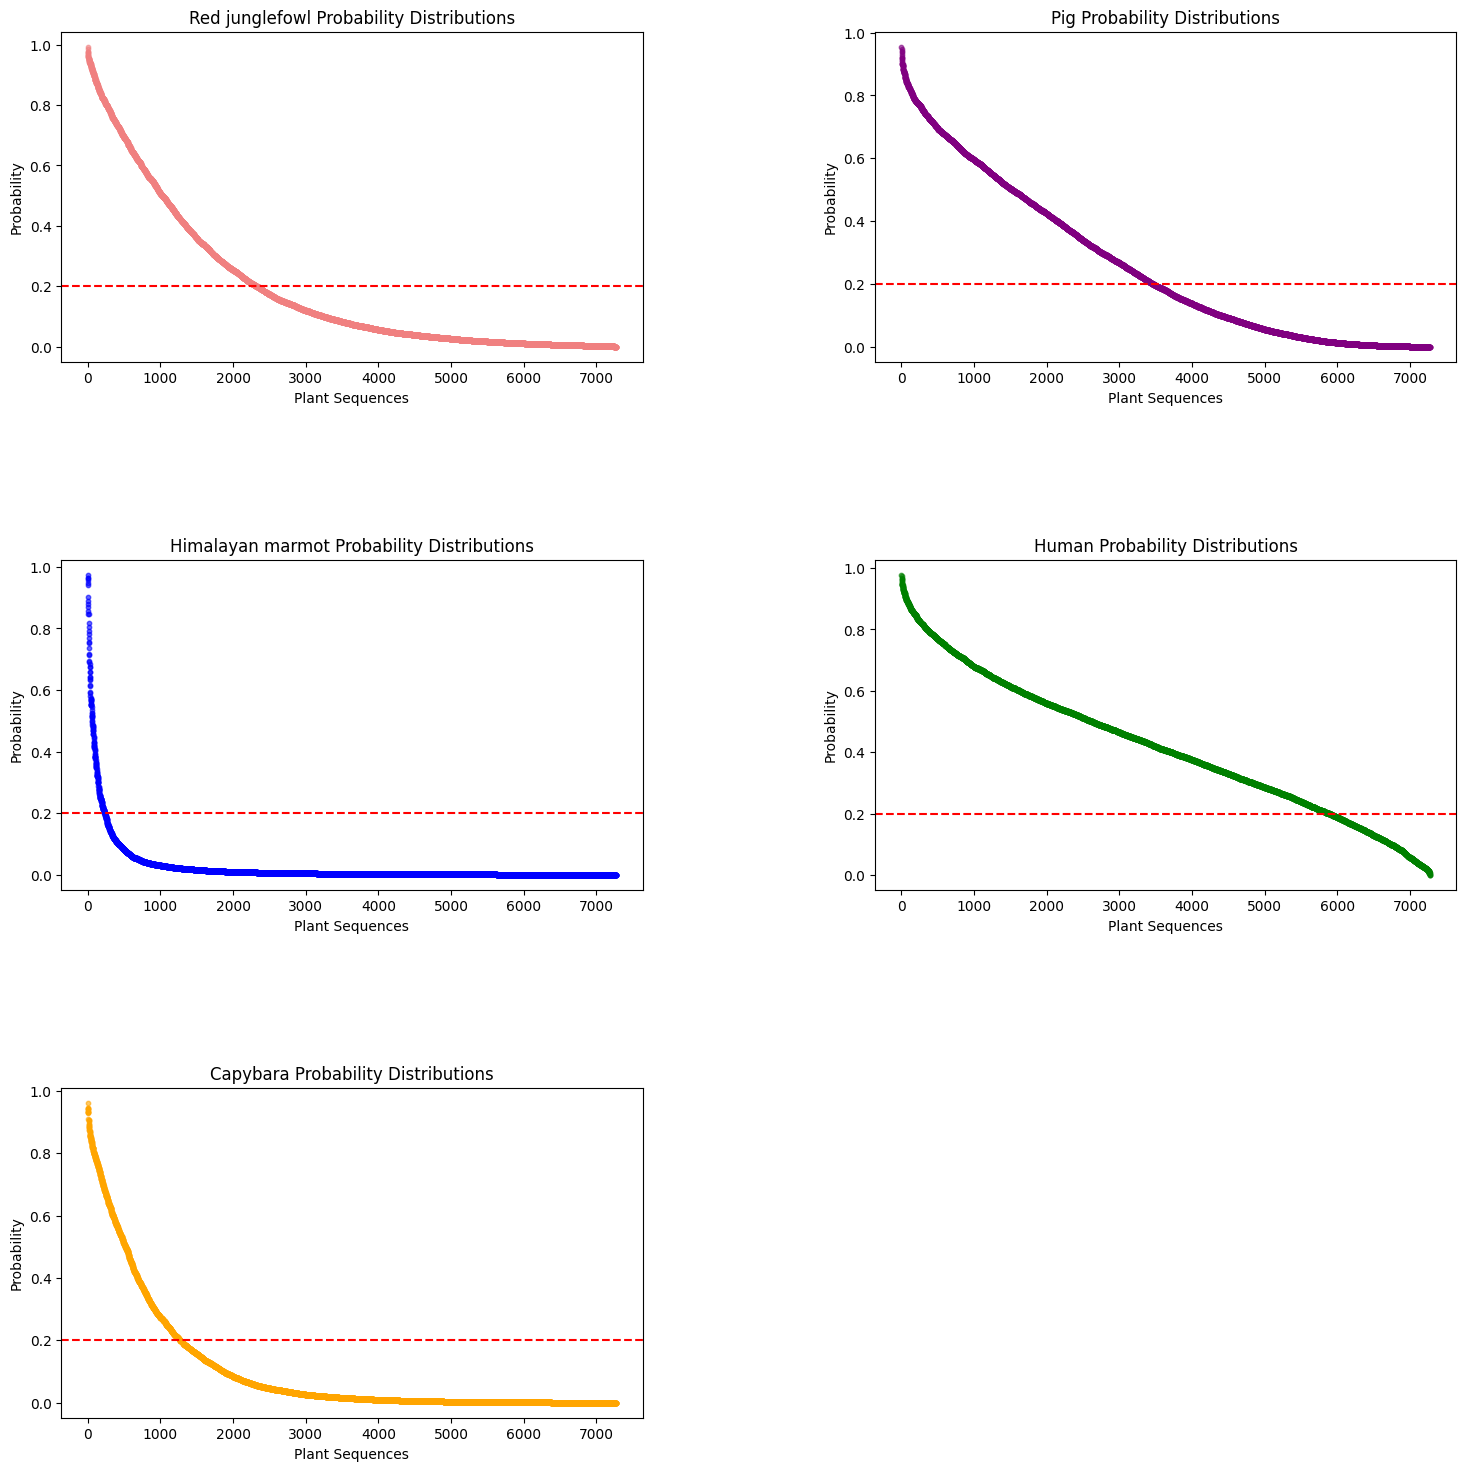

In [15]:
plt.figure(figsize=(18, 18))
plt.subplots_adjust(wspace=0.4, hspace=0.6)

threshold = 0.01
hosts = ['Red junglefowl', 'Pig', 'Himalayan marmot', 'Human', 'Capybara']
colors = ['lightcoral', 'purple', 'blue', 'green', 'orange']

for i, (host, color) in enumerate(zip(hosts, colors)):
    plt.subplot(3, 2, i + 1)
    
    y_vals = df[host].sort_values(ascending=False).values
    x_vals = range(len(y_vals))
    
    plt.scatter(x_vals, y_vals, color=color, label=host, s=10, alpha=0.6)
    plt.title(f'{host} Probability Distributions')
    plt.xlabel('Plant Sequences')
    plt.ylabel('Probability')
    plt.axhline(y=0.2, color='r', linestyle='--')

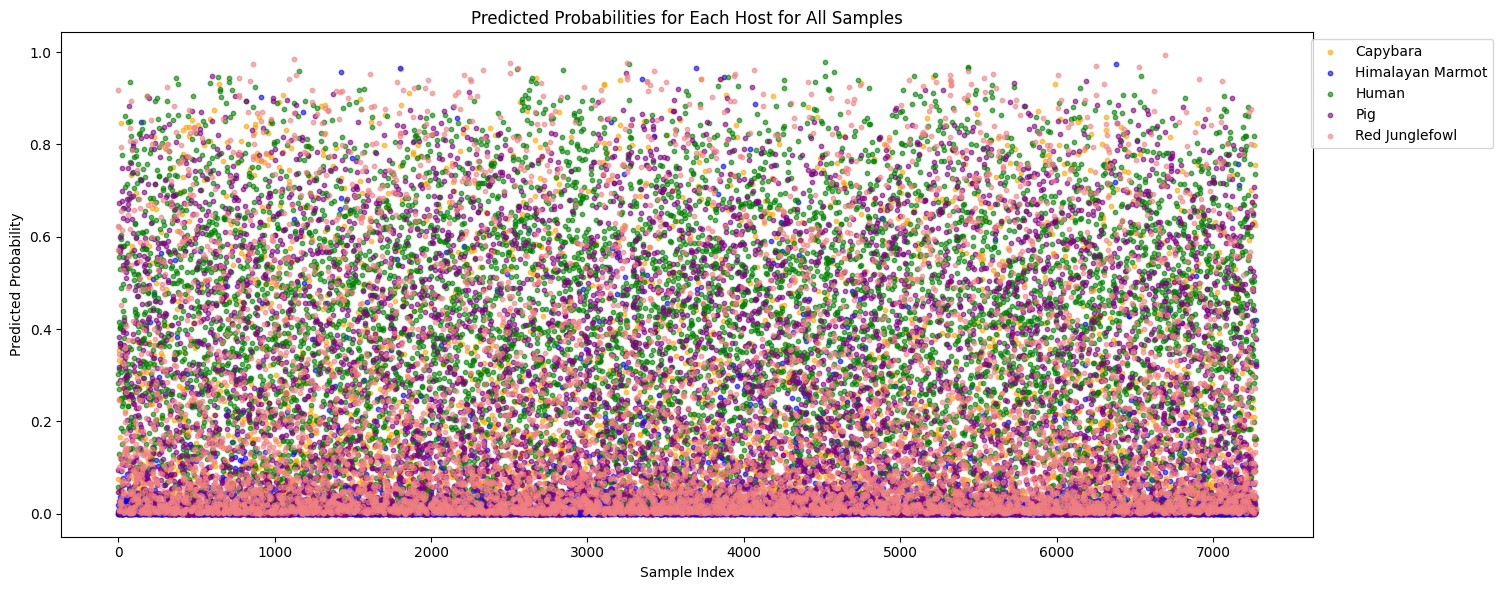

In [16]:
plt.figure(figsize=(15, 6))

x = df.index

# plot each host's probability as colored dots
plt.scatter(x, df['Capybara'], color='orange', label='Capybara', s=10, alpha=0.6)
plt.scatter(x, df['Himalayan marmot'], color='blue', label='Himalayan Marmot', s=10, alpha=0.6)
plt.scatter(x, df['Human'], color='green', label='Human', s=10, alpha=0.6)
plt.scatter(x, df['Pig'], color='purple', label='Pig', s=10, alpha=0.6)
plt.scatter(x, df['Red junglefowl'], color='lightcoral', label='Red Junglefowl', s=10, alpha=0.6)

# add labels, legend, title
plt.title('Predicted Probabilities for Each Host for All Samples')
plt.xlabel('Sample Index')
plt.ylabel('Predicted Probability')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

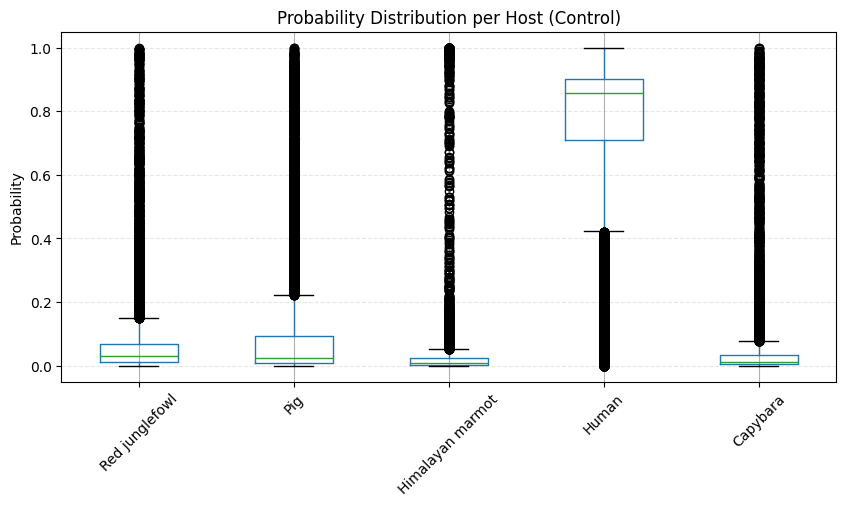

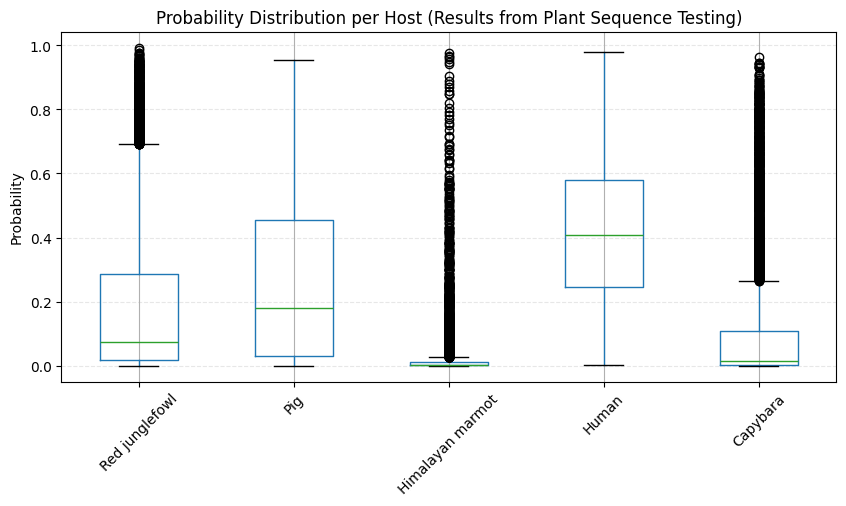

In [17]:
# box plots for control (haven trained on uniref90 filtered for vertebrate sequences)
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
vert_df[['Red junglefowl', 'Pig', 'Himalayan marmot', 'Human', 'Capybara']].boxplot()
plt.ylabel("Probability")
plt.title("Probability Distribution per Host (Control)")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)

# box plots for plant sequence testing (experimenting on haven with unseen hosts/potentially unseen viruses as well)
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 2)
df[['Red junglefowl', 'Pig', 'Himalayan marmot', 'Human', 'Capybara']].boxplot()
plt.ylabel("Probability")
plt.title("Probability Distribution per Host (Results from Plant Sequence Testing)")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)

As shown in the above box plots displaying the probability distributions for the five common hosts, Red junglefowl, Capybara, and Himalayan marmot exhibit a right skewed distribution, where most of the probabilities fall below 0.5. The Human host distribution has a mean of roughly 0.4 and displays a more normal distribution than its counterparts.

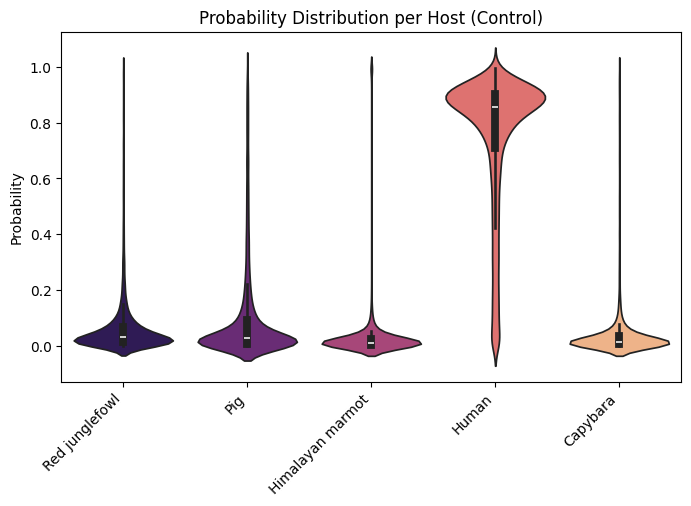

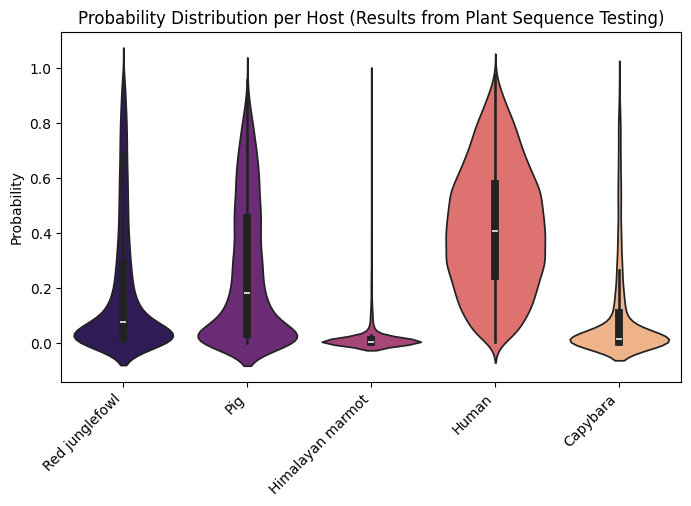

In [18]:
# same concept as above, however different visualization (violin plots)
plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 1)
sns.violinplot(vert_df[['Red junglefowl', 'Pig', 'Himalayan marmot', 'Human', 'Capybara']], palette='magma')
plt.title('Probability Distribution per Host (Control)')
plt.ylabel('Probability')
plt.xticks(ha='right', rotation=45)
plt.show()

plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 2)
sns.violinplot(df[['Red junglefowl', 'Pig', 'Himalayan marmot', 'Human', 'Capybara']], palette='magma')
plt.title('Probability Distribution per Host (Results from Plant Sequence Testing)')
plt.ylabel('Probability')
plt.xticks(ha='right', rotation=45)
plt.show()

### Statistical Analysis

##### Computing Summary Statistics & Visualizing Uncertainty via Entropy

In [19]:
# compute summary stats
def compute_stats(df, group_name, hosts):
    means = df[hosts].mean()
    stds = df[hosts].std()
    summary = means.round(3).astype(str) + " ± " + stds.round(3).astype(str)
    return pd.DataFrame({'Mean ± Std': summary}, index=hosts).rename(columns={'Mean ± Std': group_name})

stats = compute_stats(df, "Invertebrate", hosts)
summary_table = pd.concat([stats], axis=1)
print(summary_table)

                   Invertebrate
Red junglefowl    0.193 ± 0.242
Pig               0.259 ± 0.249
Himalayan marmot  0.025 ± 0.083
Human              0.417 ± 0.22
Capybara          0.106 ± 0.191


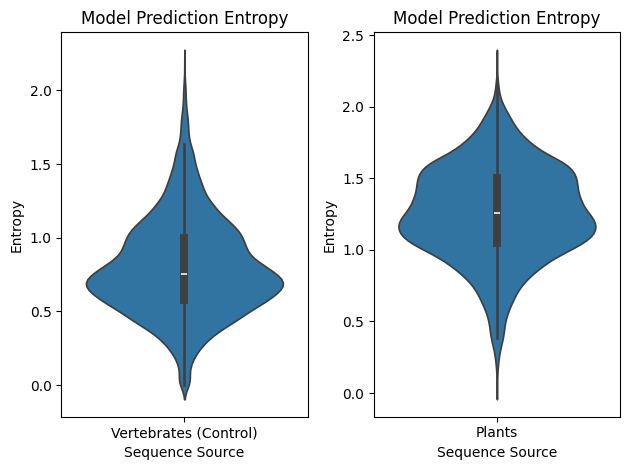

In [20]:
# define entropy function (measures the uncertainty in HAVEN's predicted host probabilities for a given viral sequencce)
# low entropy means max confidence, high means uncertain between 2 classes, outlier means maximum confusion
def add_entropy_column(df, hosts):
    df = df.copy()
    df['entropy'] = df[hosts].apply(lambda row: entropy(row.values, base=2), axis=1)
    return df

df_plant = add_entropy_column(df, hosts)
df_plant['group'] = 'Plants'

df_vert = add_entropy_column(vert_df, hosts)
df_vert['group'] = 'Vertebrates (Control)'

plt.subplot(1, 2, 1)
sns.violinplot(data=df_vert, x='group', y='entropy')
plt.title("Model Prediction Entropy")
plt.xlabel("Sequence Source")
plt.ylabel("Entropy")

plt.subplot(1, 2, 2)
sns.violinplot(data=df_plant, x='group', y='entropy')
plt.title("Model Prediction Entropy")
plt.xlabel("Sequence Source")
plt.ylabel("Entropy")

plt.tight_layout()
plt.show()

In [21]:
# summary statistics for model prediction entropy
entropy_stats = df_plant.groupby('group')['entropy'].describe()
print(entropy_stats)

         count      mean       std       min       25%       50%       75%  \
group                                                                        
Plants  7273.0  1.259825  0.328206  0.067962  1.049958  1.254686  1.499047   

             max  
group             
Plants  2.285926  


It is reasonable that the average entropy for these data is between 1 to 1.3. HAVEN is moderately uncertain, however it is seeing some familiar patterns in these sequences and hence is predicting with confidence for those specifically.

**Note**: scipy.stats.entropy function calculates Shannon entropy (H = - Σ (pk * log(pk)))

### Predictive Trends
##### Does HAVEN classify certain plant hosts repeatedly as the same host or assign different hosts (from the five common hosts) in multiple instances?

In [22]:
# get the predicted host with the highest probability for each row
df['Top_Host'] = df[hosts].idxmax(axis=1)

results = []

# create columns for storing plant host, if its always the same host, top host, and the number of sequences
for plant in df['y_true'].unique():
    subset = df[df['y_true'] == plant]
    top_host = subset['Top_Host'].iloc[0]
    always_same = (subset['Top_Host'] == top_host).all()
    
    results.append({
        'Plant': plant,
        'Always_Same_Host': always_same,
        'Top_Host': top_host,
        'Num_Sequences': len(subset)
    })

# convert results into data frame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Num_Sequences', ascending=False)

print(results_df)


                       Plant  Always_Same_Host        Top_Host  Num_Sequences
19            Allium sativum             False           Human            336
1             Vitis vinifera             False  Red junglefowl            288
45      Solanum lycopersicum             False             Pig            277
22              Prunus avium             False           Human            156
0          Solanum tuberosum             False  Red junglefowl            141
..                       ...               ...             ...            ...
701      Festuca californica              True           Human              1
307        Narcissus tazetta              True           Human              1
308   Lilium hybrid cultivar              True           Human              1
698      Pinellia tuberifera              True             Pig              1
256  Dendrocalamus brandisii              True           Human              1

[911 rows x 4 columns]


/localscratch/ipykernel_829629/2216898471.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_host_counts.index, y=top_host_counts.values, palette='magma')


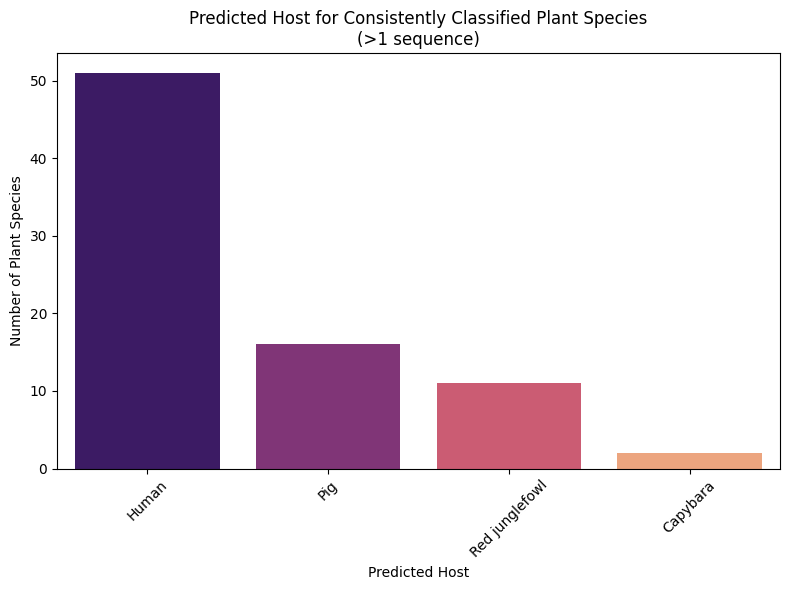

In [23]:
# defined a "consistent prediction" when it is predicting the same host for more than 1 sequencce
consistent_predictions = results_df[
    (results_df['Always_Same_Host'] == True) &
    (results_df['Num_Sequences'] > 1)
]

# count top predicted hosts
top_host_counts = consistent_predictions['Top_Host'].value_counts()

# plot, add title and axis labels
plt.figure(figsize=(8,6))
sns.barplot(x=top_host_counts.index, y=top_host_counts.values, palette='magma')

plt.title('Predicted Host for Consistently Classified Plant Species\n(>1 sequence)')
plt.xlabel('Predicted Host')
plt.ylabel('Number of Plant Species')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

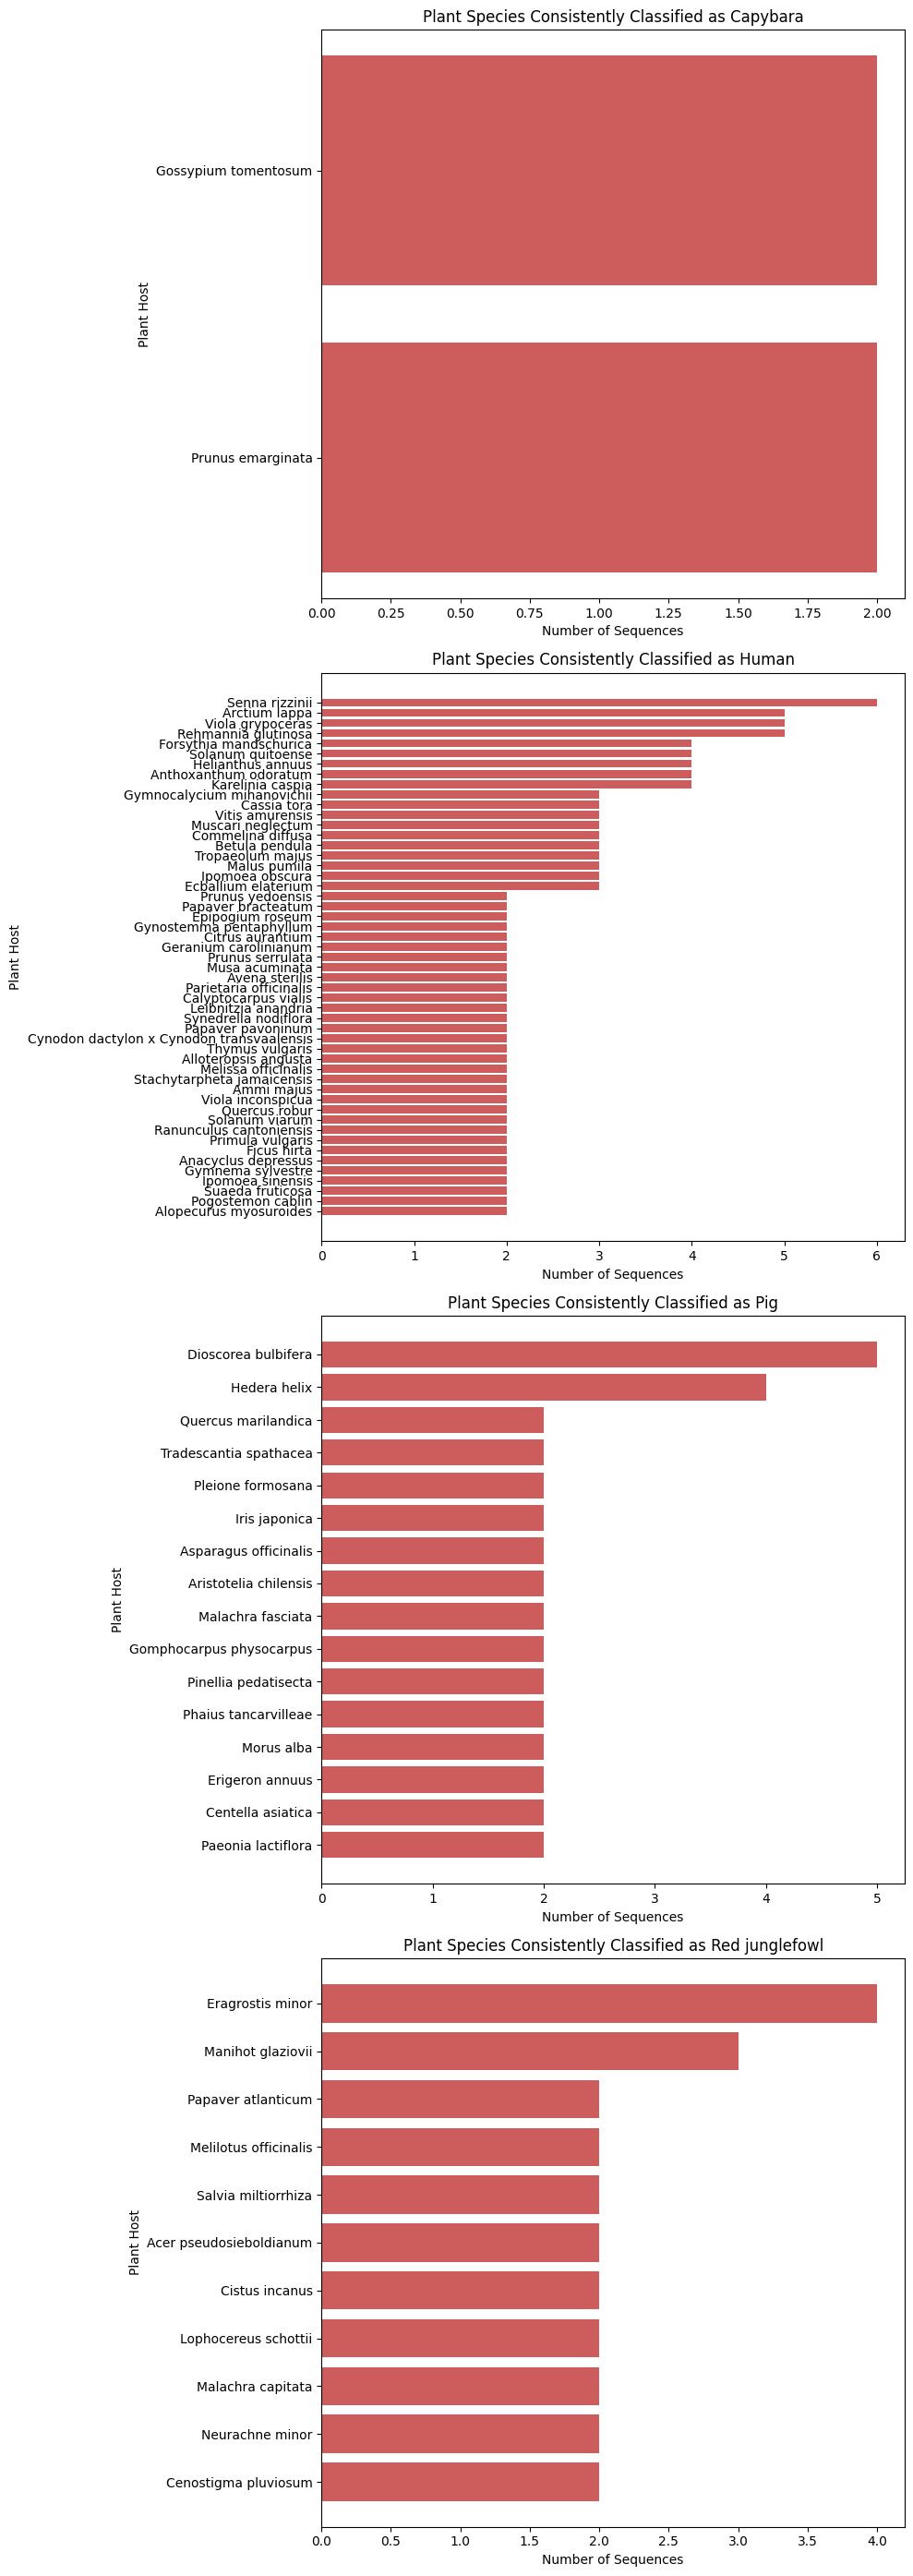

In [24]:
grouped = consistent_predictions.groupby('Top_Host')
hosts = grouped.groups.keys()
n_hosts = len(hosts)

# create subplots
fig, axes = plt.subplots(n_hosts, 1, figsize=(10, 7 * n_hosts), sharex=False)

if n_hosts == 1:
    axes = [axes]

# function to retrieve actual plant host from the consistently predicted five common hosts
for ax, host in zip(axes, hosts):
    group = grouped.get_group(host).sort_values(by='Num_Sequences', ascending=False)
    plant_names = group['Plant']
    counts = group['Num_Sequences']
    
    ax.barh(plant_names, counts, color='indianred')
    ax.set_title(f'Plant Species Consistently Classified as {host}')
    ax.set_xlabel('Number of Sequences')
    ax.set_ylabel('Plant Host')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

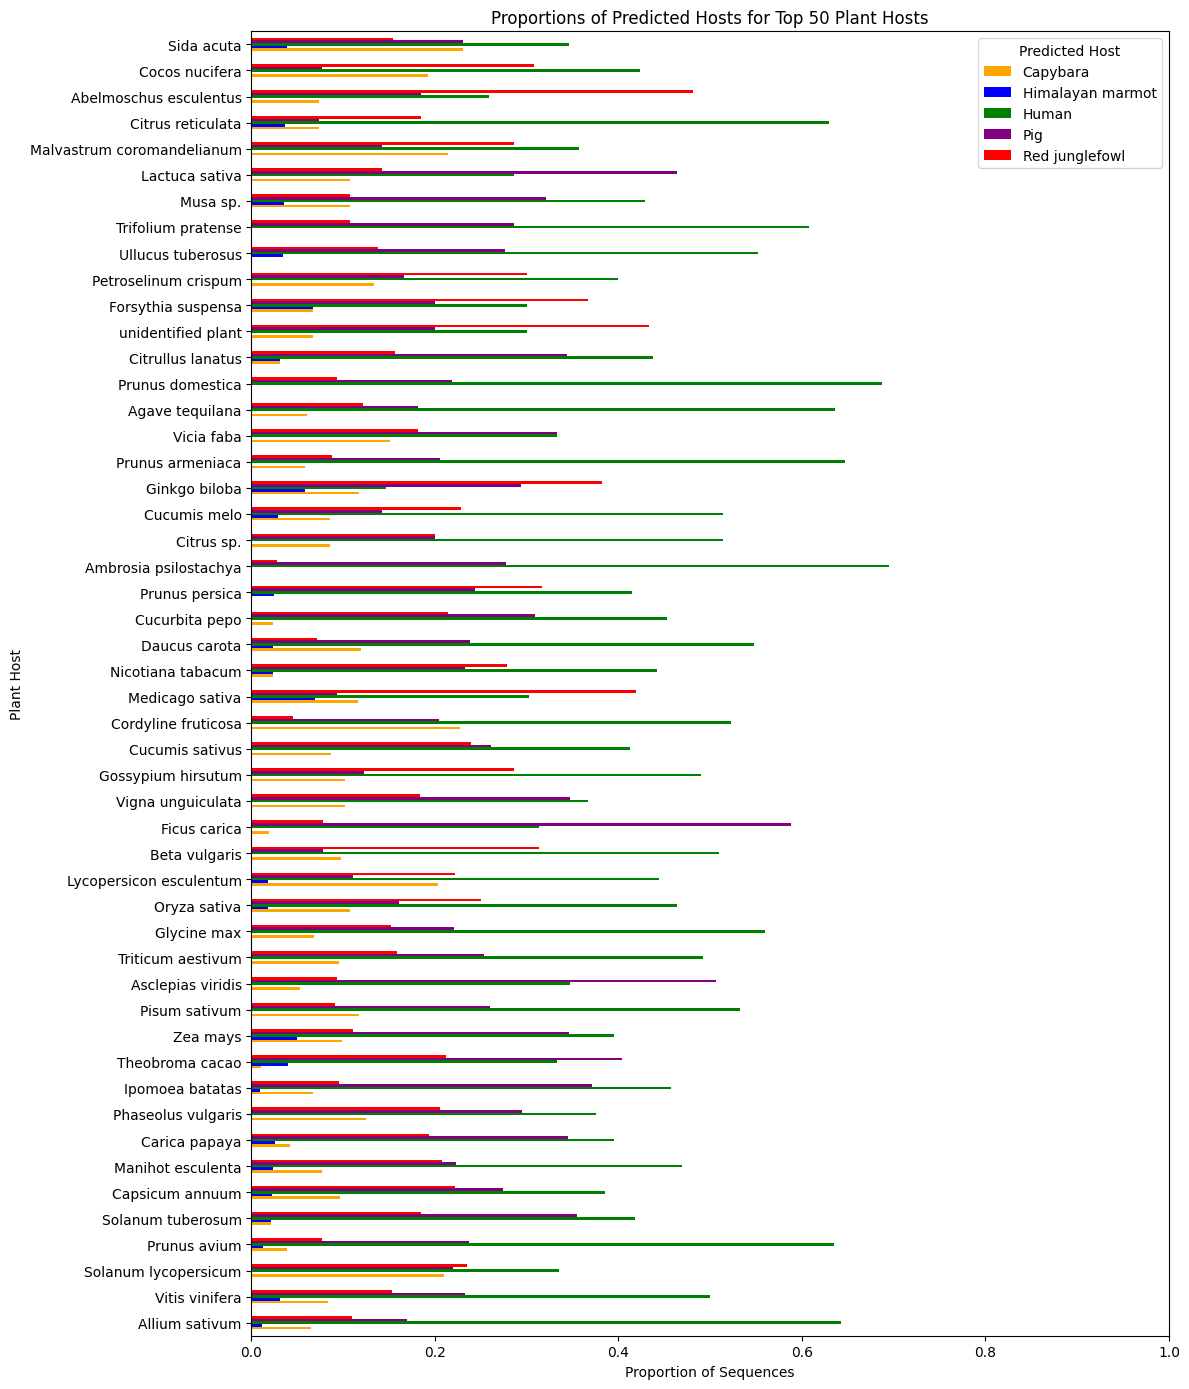

In [45]:
# get the top 50 most prevalent plants in the dataset (out of 911 total unique plant hosts)
top_50_plants = df['y_true'].value_counts().head(50).index
filtered_df = df[df['y_true'].isin(top_50_plants)].copy()

# count how many plant sequences were reported as a specific host (of the five common hosts)
counts = filtered_df.groupby(['y_true', 'Top_Host']).size().reset_index(name='count')

# count the total number of sequences for each plant host
total_per_plant = filtered_df.groupby('y_true').size().reset_index(name='total')

# perform a merge to combine two datasets (one containing the counts and the other number of sequences) together on the y_true column
# create a proportion column that divides count by total number of sequences
merged = counts.merge(total_per_plant, on='y_true')
merged['proportion'] = merged['count'] / merged['total']

# pivot/rotate the table so that y_true is the index and columns are Top_Host, values are the proportion
pivot_df = merged.pivot(index='y_true', columns='Top_Host', values='proportion').fillna(0)
pivot_df = pivot_df.loc[top_50_plants]

# plot the horizontal bar plot showing five bars for each plant host
ax = pivot_df.plot(
    kind='barh',
    stacked=False,
    figsize=(12, 14),
    color={
        'Capybara': 'orange',
        'Himalayan marmot': 'blue',
        'Human': 'green',
        'Pig': 'purple',
        'Red junglefowl': 'red',
    }
)

# configure the barplots to one graph display
plt.xlabel('Proportion of Sequences')
plt.xlim(0, 1)
plt.ylabel('Plant Host')
plt.title('Proportions of Predicted Hosts for Top 50 Plant Hosts')
plt.legend(title='Predicted Host', loc='upper right')

plt.tight_layout()
plt.show()

**Bar Chart Analysis:**
* Ambrosia psiolstachya (Western ragweed) highest proportion of sequences predicted as Human
* Ficus carcica (Fig) highest proportion of sequences predicted as Pig
* Sida acuta (common wireweed plant) highest proportion of sequences predicted as Capybara
* Abelmoschus esculentus (Okra) highest proportion of sequences predicted as Red junglefowl
* Medicago sativa (alfalfa or lucerne, perennial flowering plant) highest proportion of sequences predicted as Himalayan marmot

**Note:** idxmax function was used to retrieve the largest proportions for each of the five common hosts, therefore some hosts listed above do not appear on the bar chart graph

### Observations & Conclusions

The results show that HAVEN does decently well in predicting the host given the viral protein sequences of plant virus', ones it has not seen before in training. We expect that the model acts 'confused' when given these plant sequences and by the violin plot we notice the 'confusion' due to the increased range of probabilities and wider distributions. Some interesting findings throughout the exploratory process include Senna rizzinii (a flowering shrub) was misinterpreted as a Human six times, the highest number of all misclassifications. HAVEN consistently predicts the host as a Human, which could be potentially due to more extensive and comprehensive training data for human virus'. Another surprising finding is that HAVEN is confident that a majority of these viral protein sequences do not infect Himalayan marmots which could be due to limited data in that area, but also indicative of HAVEN's ability to make accurate and confident predictions.